In [ ]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("placement_predict_50k Dataset.csv")

print(df.shape)
print(df.head())

(50000, 32)
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4            

In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

df = pd.read_csv("placement_predict_50k Dataset.csv")

X = df.drop(columns=["PlacementStatus", "CGPA_Tier"])

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessing", preprocessor)
])

X_processed = pipeline.fit_transform(X)

print("Processed Shape:", X_processed.shape)

Processed Shape: (50000, 52)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("placement_predict_50k Dataset.csv")

# Remove rows with missing target values
df = df.dropna(subset=["PlacementStatus"])

X = df.drop(columns=["PlacementStatus", "CGPA_Tier"])
y = df["PlacementStatus"]

# Separate columns
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

# Numerical preprocessing
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Logistic Regression pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model.fit(X_train, y_train)

# Evaluate
print("Train Accuracy:", model.score(X_train, y_train))
print("Validation Accuracy:", model.score(X_val, y_val))

Train Accuracy: 0.997475
Validation Accuracy: 0.9968


In [ ]:
print("Missing values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nData types:")
print(X.dtypes)

print("\nMissing target values:")
print(y.isnull().sum())

Missing values in X:
Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
dtype: int64

Data types:
StudentID               int64
Gender                 object
City                   object
CollegeTier            object
Stream                 object
Specialisation         object
Hostel                 object
HistoryOfBacklogs      object
SGPA_Sem1             float64
SGPA_Sem2             float64
SGPA_Sem3             float64
SGPA_Sem4             float64
SGPA_Sem5             float64
SGPA_Sem6             float64
SGPA_Sem7             float64
SGPA_Sem8             float64
CGPA                  float64
AttendancePercent     float64
Internships             int64
Projects                int64
Workshops             float64
Certifications          int64
Publications            int64
AptitudeTestScore     float64
SoftSkillsRating      float64
CodingTestScore       float64
MockInterviewScore    float64
ExtraCur

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("placement_predict_50k Dataset.csv")

# Remove rows with missing target
df = df.dropna(subset=["PlacementStatus"])

# Features and target
X = df.drop(columns=["PlacementStatus", "CGPA_Tier"])
y = df["PlacementStatus"]

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Identify columns
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train
model.fit(X_train, y_train)

# Evaluate
print("Train Accuracy:", model.score(X_train, y_train))
print("Validation Accuracy:", model.score(X_val, y_val))

Train Accuracy: 0.997475
Validation Accuracy: 0.9968


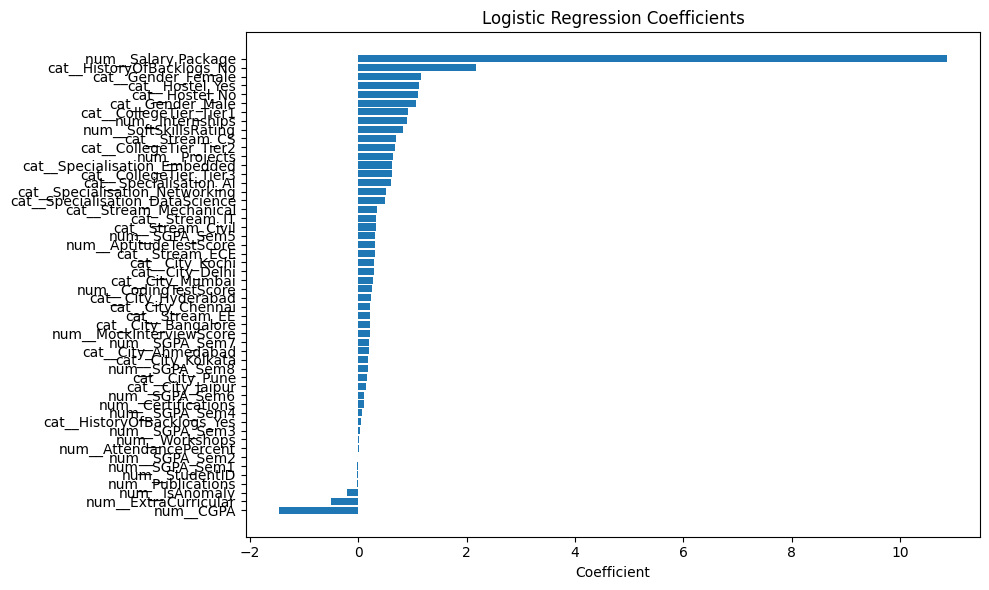

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

features = preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values("Coefficient")

plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
binary_model = model

In [ ]:
evaluate_classifier(
    binary_model, X_train, y_train, X_val, y_val
)

Train Accuracy: 0.997475
Validation Accuracy: 0.9968

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3429
           1       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
binary_model = model

multi_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs", max_iter=1000
    ))
])

third_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=0.5, max_iter=1000
    ))
])

In [ ]:
evaluate_classifier(
    binary_model, X_train, y_train, X_val, y_val
)

Train Accuracy: 0.997475
Validation Accuracy: 0.9968

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3429
           1       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

